# Activity: Bellman-Ford Shortest Path Algorithm
This activity introduces the Bellman–Ford algorithm for finding shortest paths from a single source to all other vertices in a weighted graph. Bellman–Ford handles negative edge weights (unlike Dijkstra), which makes it useful for some problems, but it is slower: time complexity is $\mathcal{O}(|\mathcal{V}|\cdot|\mathcal{E}|)$.

We'll build a small example, run the algorithm, and visualize the resulting paths so you can see how the distances and predecessors map to the plotted graph.

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

The [include command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

In [1]:
include(joinpath(@__DIR__, "Include.jl"));

[ Info: Precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a] (cache misses: wrong dep version loaded (2), incompatible header (2))


In addition to standard Julia libraries, we'll also use [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl), check out [the documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/) for more information on the functions, types and data used in this material. 

### Constants
Let's define some constants that will be used throughout the notebook. See the comment for a description of each constant, what it represents, its value, units, etc.

In [2]:
# We are going to plot the path through a graph, so let's provide the coordinates for each node, i.e., the layout
# This layout looks like our schematic but you can rearrange this if you want!
node_coordinates = [

    # source node (you)
    10.0 10.0 ; # 1 source node s (x,y) coordinates

    # people nodes (workers)
    11.0 11.0 ; # 2 people node (x,y) coordinates
    11.0 10.0 ; # 3 people node (x,y) coordinates
    11.0 9.0 ; # 4 people node (x,y) coordinates

    # job nodes (tasks)
    12.0 11.0 ; # 5 job node (x,y) coordinates
    12.0 10.0 ; # 6 job node (x,y) coordinates
    12.0 9.0 ; # 7 job node (x,y) coordinates

    # sink nodes (targets, tasks done!)
    13.0 11.0 ; # 8 sink node t (x,y) coordinates
    13.0 10.0 ; # 9 sink node t (x,y) coordinates
    13.0 9.0 ; # 10 sink node t (x,y) coordinates
];

### Implementations
Below are helper routines used in this notebook. The `flow(...)` function turns the predecessor map from the shortest-path solution into a per-edge flow array so we can highlight the edges that lie on the shortest paths.

We'll also provide a few small utility functions to parse the edge list and build the graph model. The code cells below include thorough docstrings and comments — skim the docstrings if you want the quick idea, or read the comments for implementation details.

In [3]:
"""
    function flow(graph::MySimpleDirectedGraphModel, distances::Dict{Int64, Float64}, 
        previous::Dict{Int64, Union{Nothing,Int64}})::Array{Float64,1}

Computes the flow through the graph based on the shortest path tree defined by `distances` and `previous`.

This version ignores nodes whose predecessor is `nothing` (unreachable or the source), and it safely
handles cases where an inverse-edge mapping may be missing.

### Arguments
- `graph`: The graph model instance.
- `distances`: A dictionary mapping each node to its distance from the source.
- `previous`: A dictionary mapping each node to its predecessor in the shortest path tree.

### Returns
- An array representing the flow through the graph.
"""
function flow(graph::MySimpleDirectedGraphModel, distances::Dict{Int64, Float64}, 
    previous::Dict{Int64, Union{Nothing,Int64}})::Array{Float64,1}
    
    # initialize -
    number_of_nodes = length(graph.nodes);
    number_of_edges = length(graph.edges);
    flow = zeros(Float64, number_of_edges); # initialize the flow array with zeros

    # create a inverse edge dictionary -
    inversedgemap = Dict{Tuple{Int64, Int64}, Int64}();
    for (k, v) ∈ graph.edgesinverse
        inversedgemap[v] = k;
    end

    # iterate over the nodes (skip the source at index 1)
    nodes = range(2, stop=number_of_nodes) |> collect |> reverse;
    for node ∈ nodes
        p = previous[node]; # this is a connection or nothing

        # skip nodes with no predecessor (unreachable or the source)
        if p === nothing
            continue
        end

        key = (p, node)
        if haskey(inversedgemap, key)
            i = inversedgemap[key]; # this is the edge id
            flow[i] = 1.0;
        else
            # defensive: predecessor entry exists but inverse-edge mapping missing
            @warn "Inverse edge not found for predecessor pair" node=node predecessor=p
            continue
        end
    end

    # return -
    return flow;
end;

___

## Task 1: Build a task-allocation model
You're node `1` (the source). We have a small bipartite setup: worker nodes and task nodes. Each worker can perform any task but has a preference encoded as an edge weight. Negative weight means a worker prefers that task, positive means they dislike it, and zero means indifferent.

Edges are stored in `data/Balanced-Bipartite.edgelist` with fields: `source, target, cost, lb capacity, ub capacity`. In this activity we'll ignore capacity fields and focus on costs (preferences). We'll parse the file into `MyGraphEdgeModel` instances and build a directed graph model for the Bellman–Ford run.

<div>
    <center>
        <img src="figs/Fig-BalancedSchematic-PeopleTasks-Problem.svg" width="480"/>
    </center>
</div>

We want to assign workers to tasks in a way that __minimizes the cost__ of the assignment. The graph and weights are specified in the `data/Balanced-Bipartite.edgelist` file, where each record is defined as:
> __Records__: Each record in our edgelist file has the comma separated fields: `source,` `target,` `cost,` `lb capacity,` `ub capacity`. The `source` field is the id for the source node, e.g., `1`, the `target` field is the target node id, the `cost` is the cost of assigning the source node to the target node, the `lb capacity` is the lower bound capacity for the edge, and the `ub capacity` is the upper bound capacity for the edge.

In this case study, we'll ignore the capacity constraints, but these will become important a few modules down the road, so hang tight! Ok, so now let's setup our edge parser __callback function__:

In [4]:
"""
    function edgerecordparser(record::String, delim::Char=',') -> Tuple{Int, Int, Float64} | Nothing

This method is called to parse a single edge record from the edgelist file. It gets called once for each record in the file. 
The function splits the record into fields based on the specified delimiter and extracts the source node, target node, and cost (weight) of the edge. 
It returns a tuple containing these values. If the record does not have the expected number of fields, it returns `nothing`.

### Arguments
- `record`: The edge record string to parse.
- `delim`: The delimiter used to split the record.

### Returns
- A tuple containing the source node, target node, and cost of the edge, or `nothing` if the record is invalid.
"""
function edgerecordparser(record::String, delim::Char=',')
    
    # record (five fields)
    # source, target, cost, lb, ub

    fields = split(record, delim) # this assumes a record of the form "source,target,weight"
    if length(fields) < 5 # we have 5 fields
        return nothing
    end

    # get my data -
    source = parse(Int, fields[1]) # source id
    target = parse(Int, fields[2]) # target id
    cost = parse(Float64, fields[3]) # edge weight
    
    # return a tuple -
    return (source, target, cost) # we are ignoring the capacity constraints
end;

Next, let's set the path to the edge list file in the `path_to_edge_file::String` variable:

In [5]:
path_to_edge_file = joinpath(_PATH_TO_DATA, "Balanced-Bipartite.edgelist"); # this points to the graph shown above

Next, construct a dictionary [of `MyEdgeModel` instances](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/types/#VLDataScienceMachineLearningPackage.MyGraphEdgeModel) which stores the data for the edges. Let's save our edge models in the `myedgemodels::Dict{Int64, MyGraphEdgeModel}` dictionary. 

The keys in the edge dictionary will be the edge ids (which we can assume are unique), and the values will be the corresponding `MyGraphEdgeModel` instances. Here, we've used the line index in the edgefile as the edge id.

In [6]:
myedgemodels = MyGraphEdgeModels(path_to_edge_file, edgerecordparser, delim=',', comment='#')

Dict{Int64, MyGraphEdgeModel} with 15 entries:
  5  => MyGraphEdgeModel(5, 7, 10, 0.0)
  12 => MyGraphEdgeModel(12, 4, 5, 1.0)
  8  => MyGraphEdgeModel(8, 2, 7, 1.0)
  1  => MyGraphEdgeModel(1, 1, 3, 0.0)
  0  => MyGraphEdgeModel(0, 1, 2, 0.0)
  6  => MyGraphEdgeModel(6, 2, 5, 1.0)
  11 => MyGraphEdgeModel(11, 3, 7, -1.0)
  9  => MyGraphEdgeModel(9, 3, 5, 0.0)
  14 => MyGraphEdgeModel(14, 4, 7, -2.5)
  3  => MyGraphEdgeModel(3, 5, 8, 0.0)
  7  => MyGraphEdgeModel(7, 2, 6, 0.0)
  4  => MyGraphEdgeModel(4, 6, 9, 0.0)
  13 => MyGraphEdgeModel(13, 4, 6, 1.0)
  2  => MyGraphEdgeModel(2, 1, 4, 0.0)
  10 => MyGraphEdgeModel(10, 3, 6, 1.0)

### What's our edge model tell us?
The entries in our edge model dictionary, and particularly the weight fields, give us insight into the preferences of the workers for the tasks. By analyzing the weights, we can identify which tasks are more desirable for each worker, and vice versa.

For example, consider edge(s) `11` and `14`. Edge `11` describes the preferences of worker `3` for task `7`, while edge `14` describes the preferences of worker `4` for task `7`. Thus, by comparing $w_{37}$ and $w_{47}$, we can determine which worker prefers the task more.

In [7]:
let

    # initialize -
    edge_model_11 = myedgemodels[11]; # this is the edge model for edge 11
    edge_model_14 = myedgemodels[14]; # this is the edge model for edge 14

    w37 = edge_model_11.weight; # this is the weight for edge 11
    w47 = edge_model_14.weight; # this is the weight for edge 14

    if min(w37, w47) == w37
        println("Worker 3 prefers task 7 over worker 4"); # Worker 3's preference is stronger
    else
        println("Worker 4 prefers task 7 over worker 3"); # Worker 4's preference is stronger
    end
end

Worker 4 prefers task 7 over worker 3


We could also create a weight matrix to represent the preferences of all workers for all tasks. This matrix could be used to quickly identify the most preferred task for each worker, as well as to analyze the overall distribution of preferences across workers.

> __Weight matrix:__ The weight matrix $\mathbf{W}\in\mathbb{R}^{n\times{n}}$, where $n$ is the number of nodes in the graph. Thus, $w_{ij}\in\mathbf{W}$ is the weight of the edge from node $i$ to node $j$. Most of the elements in $\mathbf{W}$ will be zero because our graph is sparse. A value of $w_{ij} = 0$ indicates __either__ no connection, or no preference between node $i$ and $j$, while $w_{ij}>0$ indicates dislike, and $w_{ij}<0$ indicates like.

We'll save the weight matrix $\mathbf{W}$ in the `W::Array{Float64,2}` variable:

In [8]:
W = let

    # build a node set from the edgemodels -
    nodes = Set{Int64}();
    for (k,v) ∈ myedgemodels
        push!(nodes, v.source);
        push!(nodes, v.target);
    end
    nodes_array = nodes |> collect |> sort;

    # create an edges dictionary -
    edges = Dict{Tuple{Int64, Int64}, Float64}();
    for (k, v) ∈ myedgemodels
        edges[(v.source, v.target)] = v.weight;
    end

    # initialize -
    n = nodes_array |> length;
    W = zeros(Float64, n, n); # this is the weight matrix

    for i ∈ 1:n
        row_index = nodes_array[i]; # this is the row index
        for j ∈ 1:n
            col_index = nodes_array[j]; # this is the column index

            # do we have an edge (row_index, col_index)?
            if haskey(edges, (row_index, col_index)) == true
                W[i,j] = edges[(row_index, col_index)];
            end

        end
    end
    W;
end

10×10 Matrix{Float64}:
 0.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  1.0  0.0   1.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  1.0  -1.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  1.0  1.0  -2.5  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0  0.0

If we look at columns $5,6,7$ (which correspond to the task nodes) we can get a sense of how desirable a particular task is. For example, if we sum each task column, we can rank each task on the basis of its desirability:

In [9]:
let

    # initialize -
    task_columns = [5,6,7];
    desirability_scores = zeros(Float64, length(task_columns));

    # compute a desirability score for each task -
    for (idx, col) ∈ enumerate(task_columns)
        desirability_scores[idx] = sum(W[:, col]); # sum the column
    end

    # rank tasks by desirability - 
    ranked_tasks = sortperm(desirability_scores, rev=false); # smallest to largest (negative is good)
    println("Task ranking based on desirability (from most to least desirable): $(task_columns[ranked_tasks])");
end

Task ranking based on desirability (from most to least desirable): [7, 5, 6]


Finally, we can build a graph instance. Since this is a directed graph, we'll construct [a `MySimpleDirectedGraphModel` instance](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/types/#VLDataScienceMachineLearningPackage.MySimpleDirectedGraphModel) using [a `build(...)` method](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/factory/#VLDataScienceMachineLearningPackage.build). Let's save our graph model in the `directedgraphmodel::MySimpleDirectedGraphModel` variable.

In [10]:
directedgraphmodel = build(MySimpleDirectedGraphModel, myedgemodels)

MySimpleDirectedGraphModel(Dict{Int64, MyGraphNodeModel}(5 => MyGraphNodeModel(5, nothing), 4 => MyGraphNodeModel(4, nothing), 6 => MyGraphNodeModel(6, nothing), 7 => MyGraphNodeModel(7, nothing), 2 => MyGraphNodeModel(2, nothing), 10 => MyGraphNodeModel(10, nothing), 9 => MyGraphNodeModel(9, nothing), 8 => MyGraphNodeModel(8, nothing), 3 => MyGraphNodeModel(3, nothing), 1 => MyGraphNodeModel(1, nothing)…), Dict{Tuple{Int64, Int64}, Number}((4, 5) => 1.0, (1, 2) => 0.0, (2, 5) => 1.0, (3, 7) => -1.0, (1, 3) => 0.0, (4, 6) => 1.0, (1, 4) => 0.0, (2, 6) => 0.0, (7, 10) => 0.0, (4, 7) => -2.5…), Dict{Int64, Set{Int64}}(5 => Set([8]), 4 => Set([5, 6, 7]), 6 => Set([9]), 7 => Set([10]), 2 => Set([5, 6, 7]), 10 => Set(), 9 => Set(), 8 => Set(), 3 => Set([5, 6, 7]), 1 => Set([4, 2, 3])…), Dict(5 => (2, 6), 12 => (4, 7), 8 => (3, 6), 1 => (1, 2), 6 => (2, 7), 11 => (4, 6), 9 => (3, 7), 14 => (6, 9), 3 => (1, 4), 7 => (3, 5)…))

## Task 2: Compute the best assignment
In this task, we'll compute the best assignment of workers to tasks, e.g., the shortest path from the source node (you) to the sink nodes (tasks done) using the Bellman-Ford algorithm.

This is a simple test case, so we can look at the edge weights and guess the shortest paths using our intuition, without running the algorithm. Let's do that so we can check if what we think should happen, actually happens.

> __Intuition:__ Suppose we specify a task node $j$. Then, the cost of having person $i$ assigned to task $j$ is just the edge weight $w_{ij}$. Thus, a minimum cost assignment for task $j$ would be: $i^{\star} \gets \arg\min_{i} w_{ij}$. Reminder: $w_{ij} = 0$ indicates no preference, $w_{ij} > 0$ indicates dislike, and $w_{ij} < 0$ indicates like.

Let's implement this intuition, and compute what we think should happen.

In [11]:
let
    # initialize -
    worker_nodes = [2,3,4]; # these are the worker nodes
    task_columns = [5,6,7]; # these are the task nodes

    for j ∈ task_columns
        # find the best worker for this task
        best_worker = argmin(W[worker_nodes, j]);
        println("Prediction: best worker for task $(j) is worker $(worker_nodes[best_worker])");
    end
end

Prediction: best worker for task 5 is worker 3
Prediction: best worker for task 6 is worker 2
Prediction: best worker for task 7 is worker 4


To compute shortest paths we call `findshortestpath(...)` with three main inputs: the graph model, the start node, and the algorithm choice (here `BellmanFordAlgorithm()`).

The function returns a distances dictionary (`d`) mapping each node to its shortest distance from the start, and a predecessors dictionary (`p`) mapping each node to its predecessor on the shortest path.

We'll run Bellman–Ford on our graph and then visualize which edges lie on the shortest paths from the source.

In [12]:
(d,p) = let
    
    # initialize -
    startnode = directedgraphmodel.nodes[1];

    # run the Bellman Ford Algorithm algorithm -
    (d,p) = findshortestpath(directedgraphmodel, startnode, algorithm = BellmanFordAlgorithm());

    (d,p) # return
end;

In [13]:
d

Dict{Int64, Float64} with 10 entries:
  5  => 0.0
  4  => 0.0
  6  => 0.0
  7  => -2.5
  2  => 0.0
  10 => -2.5
  9  => 0.0
  8  => 0.0
  3  => 0.0
  1  => 0.0

### Verification: 
Compare argmin predictions to Bellman–Ford results. This cell reconstructs shortest paths for each job node and compares the predicted best worker (from the weight matrix W) to the worker implied by the shortest-path tree (predecessors `p`).

In [14]:
using PrettyTables

let
    worker_nodes = [2,3,4]
    task_nodes = [5,6,7]

    function reconstruct_path(pmap, node)
        path = Int[]
        cur = node
        while cur !== nothing
            push!(path, cur)
            cur = get(pmap, cur, nothing)
        end
        reverse!(path)
        return path
    end

    rows = DataFrame();
    mismatches = 0

    for j in task_nodes
        dist = get(d, j, Inf)
        pred = get(p, j, nothing)
        path = reconstruct_path(p, j)

        # infer worker from reconstructed path
        algo_worker_str = "-"
        if length(path) >= 3
            candidate = path[2]
            if candidate in worker_nodes
                algo_worker_str = string(candidate)
            end
        end

        # predicted worker from weight matrix
        best_idx = argmin(W[worker_nodes, j])
        predicted_worker = worker_nodes[best_idx]

        is_match = (algo_worker_str != "-" && string(predicted_worker) == algo_worker_str)
        if !is_match
            mismatches += 1
        end

        row_df = (
            task = string(j), 
            distance = string(dist), 
            predecessor = string(pred), 
            reconstructed_path = string(path), 
            predicted_worker = string(predicted_worker), 
            algo_worker = algo_worker_str, 
            match = is_match ? "✔" : "✘"
        )

        push!(rows, row_df)
    end
    pretty_table(rows, tf = tf_simple);
end

========= ========== ============= ==================== ================== ============= =========
    task   distance   predecessor   reconstructed_path   predicted_worker   algo_worker    match 
  String     String        String               String             String        String   String 
========= ========== ============= ==================== ================== ============= =========
       5        0.0             3            [1, 3, 5]                  3             3        ✔
       6        0.0             2            [1, 2, 6]                  2             2        ✔
       7       -2.5             4            [1, 4, 7]                  4             4        ✔
========= ========== ============= ==================== ================== ============= =========


### Visualization
The plot highlights the shortest-path edges with darker, thicker arrows. Light gray arrows show other possible edges. Node positions are given by `node_coordinates`; arrows point from source to target.
> __Interpretation__: a thick black arrow means that edge is part of a shortest path from the source node. If a node is unreachable, it won't appear on a black path and its distance will be `Inf` in the `d::Dict{Int64,Float64}` dictionary.

Was our intution correct?

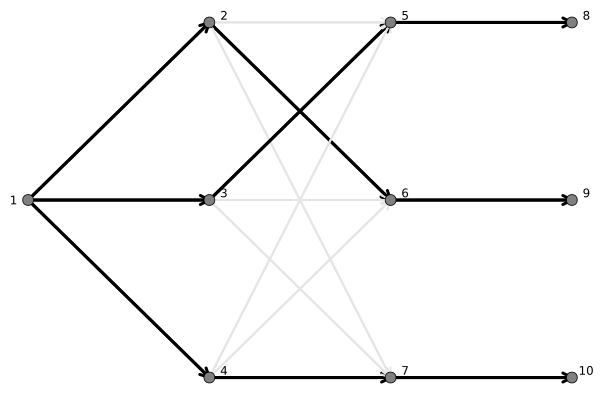

In [15]:
let
    # initialize -
    base_graphmodel = directedgraphmodel;
    q = plot(); # make an empty plot 

    # call the flow -
    f = flow(directedgraphmodel, d, p);

    # plot the nodes, and edges
    for (k,v) ∈ base_graphmodel.edgesinverse

        # get the flow value from the solution for this edge index -
        flow_value = f[k];
        
        # now, get the source,target node index for this edge
        s = v[1];
        t = v[2];

        # plot -
        if (flow_value != 0.0)
            plot!([node_coordinates[s,1], node_coordinates[t,1]],[node_coordinates[s,2], node_coordinates[t,2]], arrow=true, color=:black, lw=3, label="")
        else
            plot!([node_coordinates[s,1], node_coordinates[t,1]],[node_coordinates[s,2], node_coordinates[t,2]], arrow=true, color=:gray90, lw=2, label="")
        end
    end

    # draw nodes
    scatter!(node_coordinates[:,1], node_coordinates[:,2], axis=nothing, border=:none, label="", c=:gray, ms=6)

    # annotate nodes with their index (small offset so text does not overlap the marker)
    n_nodes = size(node_coordinates, 1)
    for i in 1:n_nodes
        x = node_coordinates[i,1]
        y = node_coordinates[i,2]
        if i == 1
            # place node 1 label to the left of the node
            annotate!(x - 0.08, y, text(string(i), 8, :black))
        else
            # existing offset for other nodes
            annotate!(x + 0.08, y + 0.04, text(string(i), 8, :black))
        end
    end

    current()
end